In [100]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [101]:
df = pd.read_csv("/content/mymoviedb.csv", engine='python', on_bad_lines='warn')

In [102]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   object 
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   object 
 5   Vote_Average       9827 non-null   object 
 6   Original_Language  9827 non-null   object 
 7   Genre              9826 non-null   object 
 8   Poster_Url         9826 non-null   object 
dtypes: float64(1), object(8)
memory usage: 691.8+ KB


In [104]:
df["Genre"].head()

,Genre
0,"Action, Adventure, Science Fiction"
1,"Crime, Mystery, Thriller"
2,Thriller
3,"Animation, Comedy, Family, Fantasy"
4,"Action, Adventure, Thriller, War"


In [105]:
df.duplicated().sum()

np.int64(0)

In [106]:
# df.describe(" Vote_Count")

In [107]:
# To get descriptive statistics for a specific column, select it first:
print("Descriptive statistics for 'Vote_Count' as object type:")
display(df['Vote_Count'].describe())

# To get numerical descriptive statistics, convert the column to a numeric type first.
# We'll use pd.to_numeric with errors='coerce' to turn non-numeric values into NaN.
df['Vote_Count_Numeric'] = pd.to_numeric(df['Vote_Count'], errors='coerce')

print("\nDescriptive statistics for 'Vote_Count' as numeric type:")
display(df['Vote_Count_Numeric'].describe())

Descriptive statistics for 'Vote_Count' as object type:


,Vote_Count
count,9827
unique,3267
top,0
freq,100



Descriptive statistics for 'Vote_Count' as numeric type:


,Vote_Count_Numeric
count,9826.000000
mean,1392.943721
std,2611.303856
min,0.000000
25%,146.000000
50%,444.000000
75%,1376.000000
max,31077.000000


In [108]:
# Convert 'Vote_Count' to numeric (float type) and update the original column
df['Vote_Count'] = pd.to_numeric(df['Vote_Count'], errors='coerce')

# Convert 'Vote_Average' to numeric (float type) and update the original column
df['Vote_Average'] = pd.to_numeric(df['Vote_Average'], errors='coerce')

# Verify the data types after conversion
print("Data types after converting 'Vote_Count' and 'Vote_Average' to float:")
df[['Vote_Count', 'Vote_Average']].info()

Data types after converting 'Vote_Count' and 'Vote_Average' to float:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Vote_Count    9826 non-null   float64
 1   Vote_Average  9826 non-null   float64
dtypes: float64(2)
memory usage: 153.8 KB


In [109]:
df.describe()

,Popularity,Vote_Count,Vote_Average,Vote_Count_Numeric
count,9827.000000,9826.000000,9826.000000,9826.000000
mean,40.320570,1392.943721,6.439467,1392.943721
std,108.874308,2611.303856,1.129797,2611.303856
min,7.100000,0.000000,0.000000,0.000000
25%,16.127500,146.000000,5.900000,146.000000
50%,21.191000,444.000000,6.500000,444.000000
75%,35.174500,1376.000000,7.100000,1376.000000
max,5083.954000,31077.000000,10.000000,31077.000000


In [110]:
df = df.drop("Vote_Count_Numeric", axis=1)

In [111]:
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9826.000000,9826.000000
mean,40.320570,1392.943721,6.439467
std,108.874308,2611.303856,1.129797
min,7.100000,0.000000,0.000000
25%,16.127500,146.000000,5.900000
50%,21.191000,444.000000,6.500000
75%,35.174500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


**Data Preprocessing**

we remove unwanted columns and also change the data types of required columns


In [112]:
df["Release_Date"] = pd.to_datetime(df["Release_Date"], errors="coerce")

print(df["Release_Date"].dtypes)

datetime64[ns]


In [113]:
df["Release_Date"] = pd.to_datetime(df["Release_Date"], errors="coerce") # Ensure it's datetime
df["Release_Date"] = df["Release_Date"].dt.year

print(df["Release_Date"].dtypes)

float64


In [114]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021.0,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940.0,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022.0,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151.0,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022.0,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122.0,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021.0,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076.0,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021.0,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793.0,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


**Dropping the columns**

In [115]:
colm = [ "Overview","Original_Language","Poster_Url"]

In [116]:
df.drop(colm , axis=1 , inplace = True)

In [117]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021.0,Spider-Man: No Way Home,5083.954,8940.0,8.3,"Action, Adventure, Science Fiction"
1,2022.0,The Batman,3827.658,1151.0,8.1,"Crime, Mystery, Thriller"
2,2022.0,No Exit,2618.087,122.0,6.3,Thriller
3,2021.0,Encanto,2402.201,5076.0,7.7,"Animation, Comedy, Family, Fantasy"
4,2021.0,The King's Man,1895.511,1793.0,7.0,"Action, Adventure, Thriller, War"


**Categorise Vote_Average column**

we make the numerical data into categoricL DATA such as Average , Popular , below average ,Not popular  ,,, we create a user define function for the same


In [118]:
def categorize_col(df, col , labels):

  edges = [df[col].describe()["min"],df[col].describe()["25%"],df[col].describe()["50%"],df[col].describe()["75%"],df[col].describe()["max"]]
  return pd.cut(df[col], bins=edges, labels=labels)



In [119]:
labels=["Not_popular","below_average","Average","Popular"]



In [120]:
categorize_col(df,"Vote_Average",labels)
df["Vote_Average"].unique()

array([ 8.3,  8.1,  6.3,  7.7,  7. ,  6.6,  6.8,  5.3,  7.2,  5.9,  7.3,
        7.1,  5.1,  4.6,  6. ,  8.2,  5.4,  6.1,  8.4,  6.9,  5.8,  7.4,
        7.8,  8. ,  6.2,  6.7,  7.6,  8.6,  4.8,  5.5,  7.9,  6.4,  7.5,
        5.7,  2.2,  6.5,  0. ,  5.6,  5.2,  5. ,  8.5,  3.5,  4. ,  3.3,
        4.7,  4.2,  4.3,  2. ,  4.1,  4.9,  8.7,  4.5,  9.1,  4.4,  3.6,
        nan,  2.8,  3.9,  3.8,  9. ,  3. ,  3.1,  3.7,  3.4,  8.9,  2.9,
        8.8,  3.2,  1.5,  9.2,  2.5,  1.8,  2.4,  2.6, 10. ])

In [121]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021.0,Spider-Man: No Way Home,5083.954,8940.0,8.3,"Action, Adventure, Science Fiction"
1,2022.0,The Batman,3827.658,1151.0,8.1,"Crime, Mystery, Thriller"
2,2022.0,No Exit,2618.087,122.0,6.3,Thriller
3,2021.0,Encanto,2402.201,5076.0,7.7,"Animation, Comedy, Family, Fantasy"
4,2021.0,The King's Man,1895.511,1793.0,7.0,"Action, Adventure, Thriller, War"


In [122]:
df["Vote_Average"].value_counts()

,count
Vote_Average,
6.4,435
6.3,429
6.5,427
6.8,423
6.7,420
...,...
9.2,1
1.8,1
2.4,1


now we split genres into a list and then explode our dataframe to have only one genre per row for each movie

In [123]:
# Assuming 'Release_Date' conversion and unwanted columns dropping have been performed in previous cells.
# Now, let's process the 'Genre' column. We convert to string, split, and then explode.
# We also handle potential 'nan' strings that result from original NaN values.
df["Genre"] = df["Genre"].astype(str).str.split(", ")
df = df.explode("Genre").reset_index(drop=True)
df = df[df['Genre'] != 'nan'] # Filter out rows where Genre is 'nan'
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021.0,Spider-Man: No Way Home,5083.954,8940.0,8.3,Action
1,2021.0,Spider-Man: No Way Home,5083.954,8940.0,8.3,Adventure
2,2021.0,Spider-Man: No Way Home,5083.954,8940.0,8.3,Science Fiction
3,2022.0,The Batman,3827.658,1151.0,8.1,Crime
4,2022.0,The Batman,3827.658,1151.0,8.1,Mystery


In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25803 entries, 0 to 25802
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Release_Date  25793 non-null  float64
 1   Title         25794 non-null  object 
 2   Popularity    25793 non-null  float64
 3   Vote_Count    25792 non-null  float64
 4   Vote_Average  25792 non-null  float64
 5   Genre         25803 non-null  object 
dtypes: float64(4), object(2)
memory usage: 1.2+ MB


In [125]:
df.nunique()

,0
Release_Date,102
Title,9514
Popularity,8160
Vote_Count,3266
Vote_Average,74
Genre,20


Data Visualization


In [126]:
sns.set_style("whitegrid")

In [127]:
df["Genre"].describe()

,Genre
count,25803
unique,20
top,Drama
freq,3744


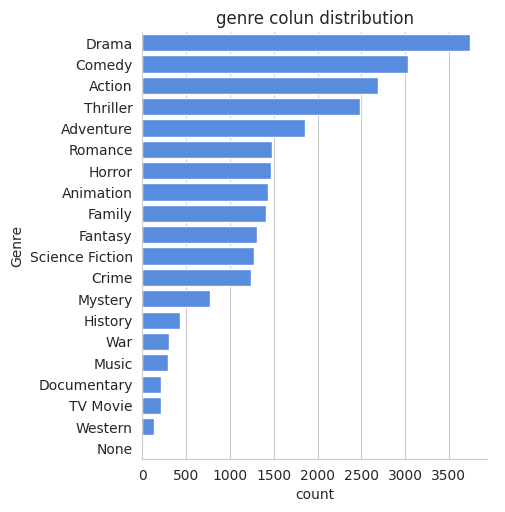

In [130]:
sns.catplot(y = 'Genre', data = df, kind='count',
            order = df['Genre'].value_counts().index,
            color='#4287f5' )
plt.title('genre colun distribution')
plt.show()



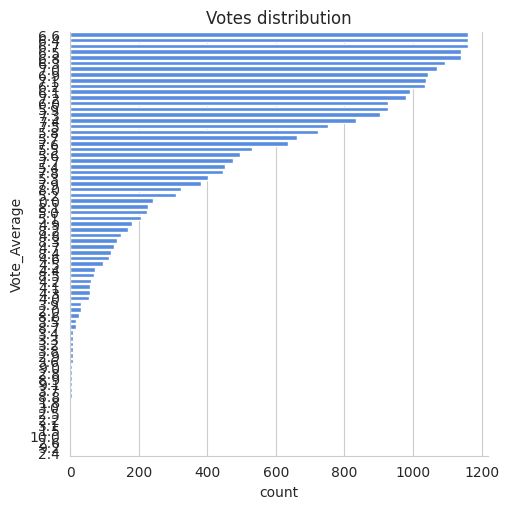

In [134]:
sns.catplot(y = 'Vote_Average', data = df, kind='count',
            order = df['Vote_Average'].value_counts().index,
            color='#4287f5' )
plt.title('Votes distribution')
plt.show()

In [136]:
df[df['Popularity']==df['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021.0,Spider-Man: No Way Home,5083.954,8940.0,8.3,Action
1,2021.0,Spider-Man: No Way Home,5083.954,8940.0,8.3,Adventure
2,2021.0,Spider-Man: No Way Home,5083.954,8940.0,8.3,Science Fiction


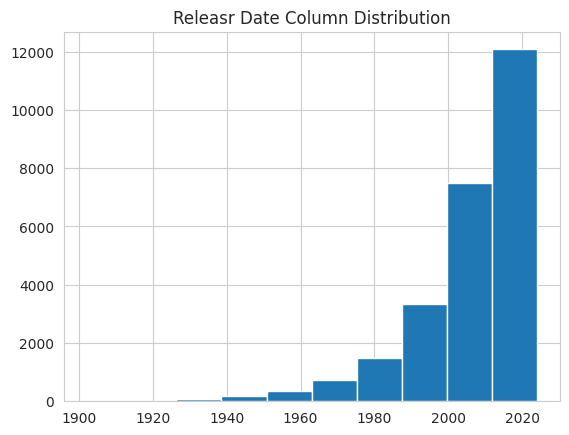

In [137]:
df['Release_Date'].hist()
plt.title('Releasr Date Column Distribution')
plt.show()